# 05 — Gaussian Process Uncertainty Quantification
### Aral Sea Water/Land Classification — AI4EO Project

This notebook uses a **Gaussian Process (GP)** to quantify the uncertainty in the CNN's water/land predictions.

**Why does uncertainty quantification matter?**

The CNN produces a hard binary label for every pixel. But some pixels — particularly at the shoreline or in shallow turbid water — sit in a spectrally ambiguous zone where the model is genuinely uncertain. The CNN gives no indication of this. A GP provides a full probability distribution over its predictions: both a mean and a **posterior variance** that tells us how confident the model is at each point.

High GP uncertainty should concentrate at the water/land transition boundary. If it does, that validates the GP as a physically meaningful uncertainty estimator.

**Technical approach:**
- Feature: NDWI (1D) — the primary spectral discriminator
- Target: CNN raw probability output (the value before the 0.5 threshold)
- Kernel: RBF (Radial Basis Function / squared exponential) + WhiteKernel noise term
- Implementation: `sklearn.gaussian_process.GaussianProcessRegressor` — mathematically identical to GPy, no compatibility issues on Colab
- Training: subsample 500 pixels — exact GP inference is O(n³), making large n intractable

**Input:** `data/processed/<year>_stack.npy`, `models/cnn_aral.h5`
**Output:** `data/processed/<year>_gp_uncertainty.npy`, figures in `figures/`

## Step 1 — Mount Drive and set paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE          = '/content/drive/MyDrive/Claude_aral'
PROCESSED_DIR = f'{BASE}/data/processed'
FIGURES_DIR   = f'{BASE}/figures'
MODELS_DIR    = f'{BASE}/models'
YEARS         = ['2016', '2022', '2026']
RANDOM_STATE  = 42

# Crop coordinates — must match IRIS mask_area from config.json
R0, C0, R1, C1 = 0, 1024, 512, 1536

print("Paths set.")

Mounted at /content/drive
Paths set.


## Step 2 — Imports

We use `sklearn.gaussian_process.GaussianProcessRegressor` with an RBF kernel.
This is mathematically identical to GPy's GP regression — same kernel, same
exact inference — with no version compatibility issues on Colab.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("All imports complete.")

All imports complete.


## Step 3 — What is a Gaussian Process?

A **Gaussian Process** is a probabilistic model that places a distribution over
functions. Rather than predicting a single value for each input, it predicts a
**Gaussian distribution** — a mean and a variance — at every point.

In our context:
- **Input (X)**: NDWI value of each pixel
- **Target (y)**: the CNN's raw probability output for that pixel
- **GP output**: at any NDWI value, the expected CNN probability *and* how uncertain that prediction is

The **RBF kernel** controls how similar two inputs are based on their distance:

$$k(x, x') = \sigma^2 \exp\left(-\frac{(x - x')^2}{2\ell^2}\right)$$

Where $\sigma^2$ is the signal variance and $\ell$ is the lengthscale.
Both are optimised automatically by maximising the marginal likelihood.

**Posterior variance** is highest where:
1. Training data is sparse
2. The CNN itself was uncertain (probability close to 0.5)

Both conditions concentrate at the water/land boundary — which is what we want to map.

## Step 4 — Load CNN and extract probability outputs

We reload the saved CNN and re-predict on the crop region to get **raw probability
outputs** (the values before the 0.5 threshold). These soft probabilities are
the GP's training targets — they tell the GP not just *what* the CNN decided,
but *how confident* it was.

In [3]:
# Reload saved CNN
model_cnn = tf.keras.models.load_model(f'{MODELS_DIR}/cnn_aral.h5')
print("CNN loaded.")

def get_ndwi_and_cnn_probs(year: str, patch_size: int = 3):
    """
    Extract NDWI values and CNN probability outputs for all valid
    pixels in the mask_area crop.

    Returns
    -------
    ndwi_vals : float32 (N,) - NDWI of each valid pixel
    cnn_probs : float32 (N,) - CNN raw probability [0, 1]
    validity  : bool (H, W)  - full scene validity mask
    stack     : float32 (H, W, 6) - full scene stack
    """
    stack    = np.load(f'{PROCESSED_DIR}/{year}_stack.npy')
    validity = np.load(f'{PROCESSED_DIR}/{year}_validity.npy')

    stack_crop    = stack[R0:R1, C0:C1, :]
    validity_crop = validity[R0:R1, C0:C1]

    pad    = patch_size // 2
    padded = np.pad(stack_crop, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')

    ys, xs  = np.where(validity_crop)
    n_valid = len(ys)
    print(f"[{year}] Extracting CNN probs for {n_valid:,} valid pixels...")

    BATCH     = 50_000
    cnn_probs = np.zeros(n_valid, dtype=np.float32)
    ndwi_vals = stack_crop[:, :, 5][validity_crop]

    for start in range(0, n_valid, BATCH):
        end   = min(start + BATCH, n_valid)
        batch = np.array([
            padded[y:y+patch_size, x:x+patch_size, :]
            for y, x in zip(ys[start:end], xs[start:end])
        ], dtype=np.float32)
        cnn_probs[start:end] = model_cnn.predict(batch, verbose=0).flatten()

    print(f"  NDWI range:     [{ndwi_vals.min():.3f}, {ndwi_vals.max():.3f}]")
    print(f"  CNN prob range: [{cnn_probs.min():.3f}, {cnn_probs.max():.3f}]")
    return ndwi_vals, cnn_probs, validity, stack


ndwi_all     = {}
cnn_prob_all = {}
validity_all = {}
stack_all    = {}

for year in YEARS:
    ndwi_v, cnn_p, val, stk = get_ndwi_and_cnn_probs(year)
    ndwi_all[year]     = ndwi_v
    cnn_prob_all[year] = cnn_p
    validity_all[year] = val
    stack_all[year]    = stk

print("\nCNN probability extraction complete.")

CNN loaded.
[2016] Extracting CNN probs for 252,860 valid pixels...
  NDWI range:     [-1.000, 1.000]
  CNN prob range: [0.000, 1.000]
[2022] Extracting CNN probs for 252,860 valid pixels...
  NDWI range:     [-1.000, 1.000]
  CNN prob range: [0.000, 1.000]
[2026] Extracting CNN probs for 252,860 valid pixels...
  NDWI range:     [-1.000, 1.000]
  CNN prob range: [0.000, 1.000]

CNN probability extraction complete.


## Step 5 — Fit Gaussian Process

We subsample 500 pixels from the 2016 scene to train the GP. The kernel is
`RBF + WhiteKernel` — the RBF captures the smooth relationship between NDWI
and CNN probability, while the WhiteKernel accounts for small observation noise.
Both kernel hyperparameters are optimised automatically.

In [4]:
def fit_gp(ndwi_vals: np.ndarray, cnn_probs: np.ndarray,
           n_train: int = 500, seed: int = 42):
    """
    Fit a GP on a subsample of NDWI -> CNN_probability pairs.
    Uses sklearn GaussianProcessRegressor with RBF + WhiteKernel.

    Returns the fitted GP model.
    """
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(ndwi_vals),
                     size=min(n_train, len(ndwi_vals)),
                     replace=False)

    X_train = ndwi_vals[idx].reshape(-1, 1).astype(np.float64)
    y_train = cnn_probs[idx].astype(np.float64)

    print(f"  Training on {len(X_train)} points...")
    print(f"  X (NDWI) range:     [{X_train.min():.3f}, {X_train.max():.3f}]")
    print(f"  y (CNN prob) range: [{y_train.min():.3f}, {y_train.max():.3f}]")

    kernel = (RBF(length_scale=0.1, length_scale_bounds=(1e-3, 10.0))
            + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 0.01)))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=3,
        normalize_y=True,
        random_state=seed
    )
    gp.fit(X_train, y_train)

    print(f"  Optimised kernel: {gp.kernel_}")
    return gp


print("Fitting GP on 2016 data...")
gp_model = fit_gp(ndwi_all['2016'], cnn_prob_all['2016'], n_train=500)
print("\nGP fitted successfully.")

Fitting GP on 2016 data...
  Training on 500 points...
  X (NDWI) range:     [-1.000, 1.000]
  y (CNN prob) range: [0.043, 1.000]
  Optimised kernel: RBF(length_scale=0.001) + WhiteKernel(noise_level=0.01)

GP fitted successfully.


## Step 6 — Visualise the GP fit

We plot how CNN probability varies with NDWI, with the GP posterior mean and
95% confidence interval. The confidence band should be widest near NDWI = 0
where data is most ambiguous.

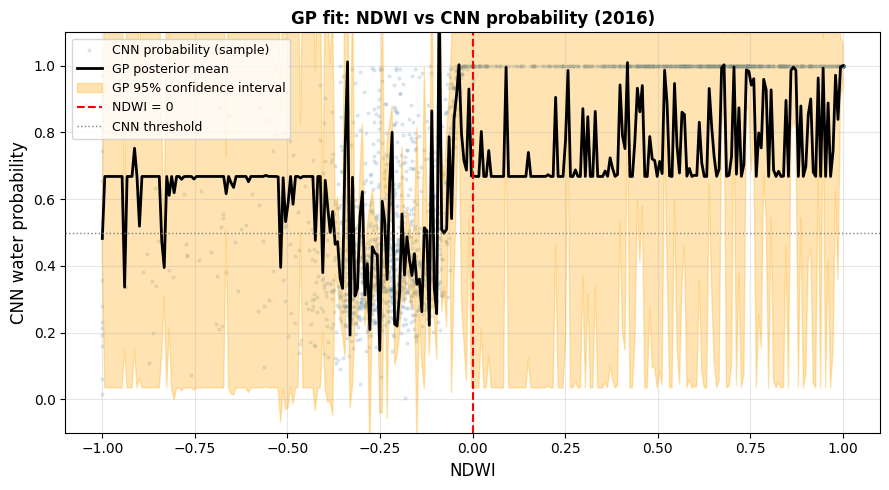

Figure saved: /content/drive/MyDrive/Claude_aral/figures/gp_fit_2016.png


In [5]:
def plot_gp_fit(gp, ndwi_vals, cnn_probs, year):
    x_plot = np.linspace(ndwi_vals.min(), ndwi_vals.max(), 300).reshape(-1, 1)
    mean, std = gp.predict(x_plot.astype(np.float64), return_std=True)

    fig, ax = plt.subplots(figsize=(9, 5))

    # Scatter a subsample of data points
    rng = np.random.default_rng(0)
    idx = rng.choice(len(ndwi_vals), size=min(2000, len(ndwi_vals)), replace=False)
    ax.scatter(ndwi_vals[idx], cnn_probs[idx], alpha=0.15, s=4,
               color='steelblue', label='CNN probability (sample)')

    ax.plot(x_plot, mean, 'k-', linewidth=2, label='GP posterior mean')
    ax.fill_between(x_plot.flatten(),
                    mean - 2*std,
                    mean + 2*std,
                    alpha=0.3, color='orange',
                    label='GP 95% confidence interval')

    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='NDWI = 0')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='CNN threshold')
    ax.set_xlabel('NDWI', fontsize=12)
    ax.set_ylabel('CNN water probability', fontsize=12)
    ax.set_title(f'GP fit: NDWI vs CNN probability ({year})',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.1, 1.1)

    plt.tight_layout()
    out = f'{FIGURES_DIR}/gp_fit_{year}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')


plot_gp_fit(gp_model, ndwi_all['2016'], cnn_prob_all['2016'], '2016')

## Step 7 — Generate full-scene uncertainty maps

We apply the fitted GP to every valid pixel's NDWI value to produce:
1. **GP mean map** — smooth estimate of CNN probability
2. **GP uncertainty map** — posterior standard deviation per pixel

High uncertainty should cluster at the water/land boundary where NDWI ≈ 0.

In [6]:
def predict_uncertainty_map(year: str, gp):
    """
    Apply GP to all valid pixels in the crop to produce
    mean and uncertainty (std dev) maps.
    """
    stack    = stack_all[year]
    validity = validity_all[year]

    ndwi_crop = stack[R0:R1, C0:C1, 5]
    val_crop  = validity[R0:R1, C0:C1]
    H_crop    = R1 - R0
    W_crop    = C1 - C0

    ndwi_valid = ndwi_crop[val_crop].astype(np.float64).reshape(-1, 1)
    n_valid    = ndwi_valid.shape[0]
    print(f"[{year}] Predicting for {n_valid:,} pixels...")

    BATCH = 10_000
    means = np.zeros(n_valid, dtype=np.float32)
    stds  = np.zeros(n_valid, dtype=np.float32)

    for start in range(0, n_valid, BATCH):
        end       = min(start + BATCH, n_valid)
        m, s      = gp.predict(ndwi_valid[start:end], return_std=True)
        means[start:end] = m.flatten().astype(np.float32)
        stds[start:end]  = s.flatten().astype(np.float32)

    mean_map = np.full((H_crop, W_crop), np.nan, dtype=np.float32)
    std_map  = np.full((H_crop, W_crop), np.nan, dtype=np.float32)
    mean_map[val_crop] = means
    std_map[val_crop]  = stds

    print(f"  Mean uncertainty: {np.nanmean(std_map):.4f}")
    print(f"  Max uncertainty:  {np.nanmax(std_map):.4f}")

    np.save(f'{PROCESSED_DIR}/{year}_gp_mean.npy',        mean_map)
    np.save(f'{PROCESSED_DIR}/{year}_gp_uncertainty.npy', std_map)
    print(f"  Saved.")
    return mean_map, std_map


gp_means = {}
gp_stds  = {}

for year in YEARS:
    mean_map, std_map = predict_uncertainty_map(year, gp_model)
    gp_means[year] = mean_map
    gp_stds[year]  = std_map

print("\nAll uncertainty maps complete.")

[2016] Predicting for 252,860 pixels...
  Mean uncertainty: 0.1661
  Max uncertainty:  0.3167
  Saved.
[2022] Predicting for 252,860 pixels...
  Mean uncertainty: 0.1579
  Max uncertainty:  0.3167
  Saved.
[2026] Predicting for 252,860 pixels...
  Mean uncertainty: 0.1374
  Max uncertainty:  0.3167
  Saved.

All uncertainty maps complete.


## Step 8 — Visualise uncertainty maps

For each year: NDWI reference, GP posterior mean, and GP uncertainty map.

In [7]:
for year in YEARS:
    stack    = stack_all[year]
    validity = validity_all[year]

    ndwi_crop = stack[R0:R1, C0:C1, 5].copy()
    val_crop  = validity[R0:R1, C0:C1]
    ndwi_crop[~val_crop] = np.nan

    mean_map = gp_means[year].copy()
    std_map  = gp_stds[year].copy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'GP Uncertainty Quantification ({year})',
                 fontsize=13, fontweight='bold')

    im0 = axes[0].imshow(ndwi_crop, cmap='RdYlBu', vmin=-0.5, vmax=0.5)
    axes[0].set_title('NDWI reference', fontweight='bold')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(mean_map, cmap='RdYlBu', vmin=0, vmax=1)
    axes[1].set_title('GP posterior mean\n(smoothed water probability)',
                      fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='P(water)')

    im2 = axes[2].imshow(std_map, cmap='YlOrRd', vmin=0, vmax=0.3)
    axes[2].set_title('GP uncertainty\n(posterior std dev)',
                      fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label='Uncertainty')

    plt.tight_layout()
    out = f'{FIGURES_DIR}/gp_uncertainty_{year}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')

Output hidden; open in https://colab.research.google.com to view.

## Step 9 — Uncertainty profile across NDWI values

This is the key validation plot. GP uncertainty should peak near NDWI = 0 —
the transition zone where the spectral signal is ambiguous. If it does,
the GP is capturing physically real uncertainty, not just model noise.

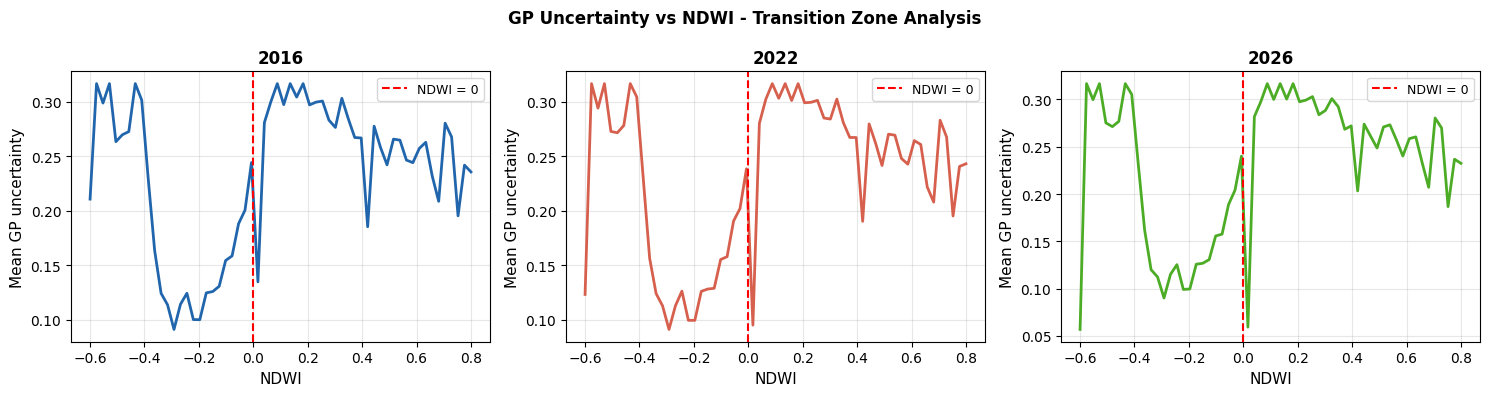

Figure saved: /content/drive/MyDrive/Claude_aral/figures/gp_uncertainty_profile.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('GP Uncertainty vs NDWI - Transition Zone Analysis',
             fontsize=12, fontweight='bold')

colours = ['#2166AC', '#D6604D', '#4DAC26']

for ax, year, colour in zip(axes, YEARS, colours):
    val_crop  = validity_all[year][R0:R1, C0:C1]
    ndwi_crop = stack_all[year][R0:R1, C0:C1, 5]

    ndwi_v = ndwi_crop[val_crop]
    std_v  = gp_stds[year][val_crop]

    bins      = np.linspace(-0.6, 0.8, 60)
    bin_idx   = np.digitize(ndwi_v, bins)
    bin_means = [std_v[bin_idx == i].mean()
                 if (bin_idx == i).sum() > 10 else np.nan
                 for i in range(len(bins))]

    ax.plot(bins, bin_means, color=colour, linewidth=2)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5,
               label='NDWI = 0')
    ax.set_xlabel('NDWI', fontsize=11)
    ax.set_ylabel('Mean GP uncertainty', fontsize=11)
    ax.set_title(year, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out = f'{FIGURES_DIR}/gp_uncertainty_profile.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

## Step 10 — Compare GP uncertainty with GMM uncertainty

The GMM (notebook 03) also produced an uncertainty map. If both methods
independently flag the same pixels as uncertain, that is strong convergent
evidence the uncertainty is real and physically meaningful.

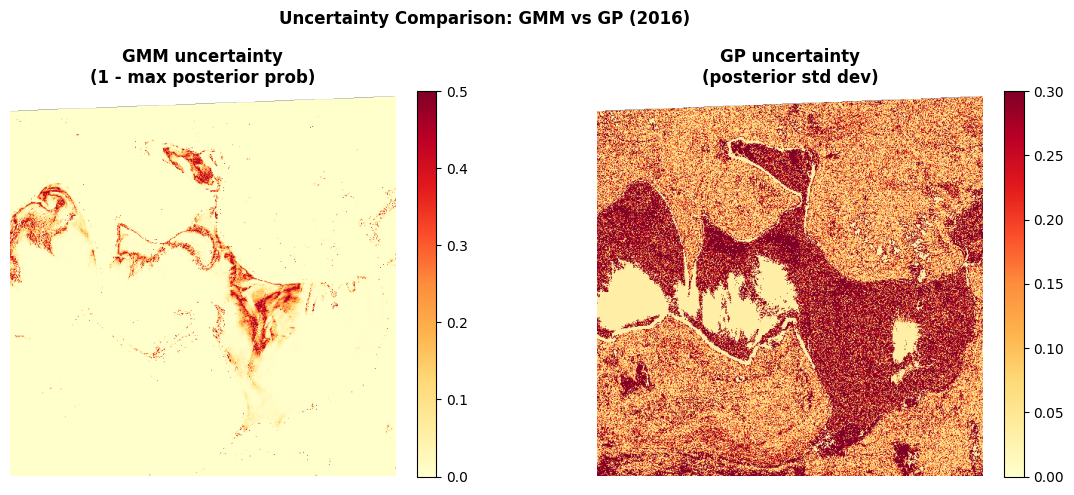

Figure saved: /content/drive/MyDrive/Claude_aral/figures/uncertainty_comparison_2016.png

Correlation between GMM and GP uncertainty: 0.194
Values closer to 1.0 = both methods agree on which pixels are uncertain.


In [9]:
year     = '2016'
val_crop = validity_all[year][R0:R1, C0:C1]

try:
    gmm_unc_full = np.load(f'{PROCESSED_DIR}/{year}_gmm_uncertainty.npy')
    gmm_unc_crop = gmm_unc_full[R0:R1, C0:C1].copy()
    gmm_unc_crop[~val_crop] = np.nan
    gp_unc_crop  = gp_stds[year].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Uncertainty Comparison: GMM vs GP ({year})',
                 fontsize=12, fontweight='bold')

    im0 = axes[0].imshow(gmm_unc_crop, cmap='YlOrRd', vmin=0, vmax=0.5)
    axes[0].set_title('GMM uncertainty\n(1 - max posterior prob)',
                      fontweight='bold')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(gp_unc_crop, cmap='YlOrRd', vmin=0, vmax=0.3)
    axes[1].set_title('GP uncertainty\n(posterior std dev)',
                      fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    out = f'{FIGURES_DIR}/uncertainty_comparison_2016.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')

    gmm_v = gmm_unc_crop[val_crop]
    gp_v  = gp_unc_crop[val_crop]
    corr  = np.corrcoef(gmm_v, gp_v)[0, 1]
    print(f'\nCorrelation between GMM and GP uncertainty: {corr:.3f}')
    print('Values closer to 1.0 = both methods agree on which pixels are uncertain.')

except FileNotFoundError:
    print("GMM uncertainty file not found.")
    print("Make sure 03_unsupervised.ipynb ran to completion first.")

## Summary

This notebook applied a Gaussian Process to quantify uncertainty in CNN predictions.

**Key outputs saved:**
- `data/processed/<year>_gp_mean.npy` — GP posterior mean map
- `data/processed/<year>_gp_uncertainty.npy` — GP posterior std dev (uncertainty)
- GP fit plot, uncertainty maps per year, uncertainty profile, GMM vs GP comparison

**Points to discuss in your report:**
- Does the uncertainty peak near NDWI = 0? (validates GP physically)
- Do GMM and GP uncertainty maps agree spatially? (convergent evidence)
- Does uncertainty increase in 2022/2026 vs 2016? (temporal generalisation)
- How does GP uncertainty improve on the CNN's raw binary output?

**Next:** `06_evaluation.ipynb` — formal comparison of all methods.